# A2C / A3C: Advantage Actor-Critic

**A hands-on tutorial with theory and PyTorch implementation**

---

In 2016 DeepMind published *Asynchronous Methods for Deep Reinforcement Learning*
([Mnih et al., 2016](https://arxiv.org/abs/1602.01783)). Its headline algorithm, **A3C** (Asynchronous Advantage
Actor-Critic), matched or beat DQN on Atari in *half the wall-clock time on a single 16-core CPU* — no GPU, no replay
buffer. The key idea was to run many copies of the environment in parallel, each with its own actor, and let their
decorrelated experience replace experience replay. That made *on-policy* deep RL practical for the first time, and
the actor-critic template it established — a policy head and a value head sharing a network, trained with $n$-step
advantages and an entropy bonus — is what PPO, IMPALA and most modern policy-gradient systems are built on.

**A2C** is the synchronous variant popularized by OpenAI Baselines: instead of asynchronous, lock-free updates from
many threads, all environments step in lock-step and one batched gradient step is taken. It performs the same
computation deterministically and uses the GPU efficiently, so it is the form everyone actually uses today.

## What you will learn

1. What a **critic** adds to REINFORCE: bootstrapped $n$-step returns and advantage estimates.
2. The **A3C/A2C loss**: policy gradient + value regression + entropy bonus, on a shared network.
3. Why **parallel environments** replace the replay buffer for on-policy methods.
4. A **from-scratch PyTorch implementation** on `Acrobot-v1`, a sparse-reward swing-up task.
5. How A2C relates to REINFORCE, PPO and IMPALA.

## Notebook outline

1. Actor-critic methods
2. $n$-step returns and the advantage
3. The A3C / A2C algorithm
4. Parallelism: asynchronous vs. synchronous
5. Implementation
6. Training on Acrobot
7. **Visual demonstration** of the trained agent
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

In [4]:
def moving_average(x, w=20):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

## 1. Actor-Critic Methods

REINFORCE estimates the policy gradient with Monte Carlo returns:

$$
\nabla_\theta J(\theta) = \mathbb{E}\Big[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t)\; \big(G_t - b(s_t)\big)\Big].
$$

It has to wait for the episode to end to compute $G_t$, and $G_t$ is a very noisy estimate of $Q^\pi(s_t, a_t)$.
An **actor-critic** method keeps the policy (the **actor**, $\pi_\theta$) but adds a learned value function (the
**critic**, $V_\phi$) that is used not just as a baseline but to **bootstrap** — to replace the tail of the return with
an estimate:

$$
G_t \approx r_t + \gamma V_\phi(s_{t+1}) \qquad\text{(one-step)}.
$$

Now an update can be made after every step, from an incomplete episode, with much lower variance — at the price of
**bias** whenever $V_\phi$ is wrong. Actor-critic methods (Barto, Sutton & Anderson, 1983; Konda & Tsitsiklis, 2000)
are the sample-based version of *generalized policy iteration*: the critic evaluates, the actor improves.

## 2. $n$-Step Returns and the Advantage

A3C uses the **$n$-step return**, which bootstraps after $n$ real rewards:

$$
G^{(n)}_t \;=\; r_t + \gamma r_{t+1} + \cdots + \gamma^{n-1} r_{t+n-1} + \gamma^n V_\phi(s_{t+n}).
$$

$n = 1$ is one-step TD (lowest variance, most bias); $n \to \infty$ recovers Monte Carlo. A3C used $n = 5$ for Atari,
which lets a reward propagate 5 steps back in a single update instead of one. (If an episode ends inside the window,
the bootstrap term is dropped.)

The **advantage** of an action is how much better it was than the policy's average from that state:

$$
\hat A_t \;=\; G^{(n)}_t - V_\phi(s_t).
$$

Using $\hat A_t$ instead of $G_t$ as the weight in the policy gradient is the "advantage" in *Advantage Actor-Critic*.
PPO's Generalized Advantage Estimation is an exponentially-weighted average of all $n$-step advantages; A2C simply uses
one fixed $n$.

## 3. The A3C / A2C Algorithm

Both actor and critic are heads on a **shared network** $f_\theta(s)$ (in Atari, a shared CNN; here a shared MLP).
The loss combines three terms:

$$
\boxed{\;
L(\theta) \;=\; \underbrace{-\,\mathbb{E}_t\big[\log \pi_\theta(a_t|s_t)\,\hat A_t\big]}_{\text{policy gradient}}
\;+\; c_v\, \underbrace{\mathbb{E}_t\big[(G^{(n)}_t - V_\theta(s_t))^2\big]}_{\text{value regression}}
\;-\; c_e\, \underbrace{\mathbb{E}_t\big[\mathcal{H}\big(\pi_\theta(\cdot|s_t)\big)\big]}_{\text{entropy bonus}}
\;}
$$

- The **advantage is treated as a constant** in the policy term (`detach`): the critic's gradient must not flow into
  the actor through $\hat A_t$.
- The **entropy bonus** $\mathcal{H}(\pi) = -\sum_a \pi(a|s)\log\pi(a|s)$ (Williams & Peng, 1991) discourages premature
  convergence to a deterministic policy — it is the exploration mechanism of A3C, which has no $\varepsilon$-greedy.
- Typical coefficients: $c_v = 0.5$, $c_e = 0.01$.

**Algorithm (A2C, one iteration):**

1. Run $N$ parallel environments for $n$ steps with the current policy, storing $(s, a, r, \text{done}, V(s))$.
2. Bootstrap from $V_\theta(s_{t+n})$ and compute $n$-step returns and advantages backwards.
3. One gradient step on $L(\theta)$ using all $N \times n$ samples. Discard the data.

## 4. Parallelism: Asynchronous vs. Synchronous

On-policy methods cannot use a replay buffer (the data must come from the *current* policy), so how do we break the
correlation between consecutive samples that DQN solved with replay? A3C's answer: **run many environments at once**.
Different copies of the environment are in different states, so a batch drawn across them is diverse.

- **A3C** launches one thread per CPU core, each with its own environment and a *local copy* of the network. Each thread
  computes gradients on its own $n$-step rollout and applies them to a *shared* global network without locks
  (Hogwild!-style), then re-syncs its local copy. It is fast and needs no GPU, but the updates are stale and
  non-deterministic.
- **A2C** steps all environments in lock-step, computes one batched gradient from all of them, and applies it
  synchronously. It gives up asynchrony but is simpler, reproducible, and uses batched GPU inference. OpenAI reported no
  loss in performance from the synchronous version.

`gymnasium.vector.SyncVectorEnv` gives us $N$ environments in lock-step in one process, which is exactly what A2C needs.
(`AsyncVectorEnv` runs them in subprocesses for throughput; the algorithm is unchanged.)

## 5. Implementation

### 5.1 Environment and hyperparameters

`Acrobot-v1` is a two-link pendulum hanging down; the goal is to swing the tip above a line by applying torque at the
joint. Reward is $-1$ per step until success (or a 500-step timeout), so the only learning signal is *finishing
sooner* — a much sparser signal than CartPole's, and a nice test of whether bootstrapping and parallel exploration work.
Returns above $-100$ count as solved.

In [5]:
@dataclass
class A2CConfig:
    env_id: str = "Acrobot-v1"
    num_envs: int = 16
    n_steps: int = 5                # the "n" in n-step returns; A3C used 5
    total_timesteps: int = 400_000
    gamma: float = 0.99
    lr: float = 7e-4                # A3C used RMSprop with lr ~7e-4
    rms_alpha: float = 0.99
    rms_eps: float = 1e-5
    value_coef: float = 0.5
    entropy_coef: float = 0.01
    max_grad_norm: float = 0.5
    hidden: int = 64
    reward_scale: float = 0.1       # see the note in 5.4: keeps the value loss on a sane scale
    log_interval: int = 250         # updates


cfg = A2CConfig()
cfg.batch_size = cfg.num_envs * cfg.n_steps
print(cfg)

A2CConfig(env_id='Acrobot-v1', num_envs=16, n_steps=5, total_timesteps=400000, gamma=0.99, lr=0.0007, rms_alpha=0.99, rms_eps=1e-05, value_coef=0.5, entropy_coef=0.01, max_grad_norm=0.5, hidden=64, reward_scale=0.1, log_interval=250)


### 5.2 Shared actor-critic network

One trunk, two heads: policy logits and a scalar value. As in the PPO notebook we use orthogonal initialization, with
a small gain on the policy head so the initial policy is close to uniform.

In [6]:
def layer_init(layer, std=math.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class ActorCritic(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.trunk = nn.Sequential(layer_init(nn.Linear(obs_dim, hidden)), nn.Tanh(),
                                   layer_init(nn.Linear(hidden, hidden)), nn.Tanh())
        self.policy_head = layer_init(nn.Linear(hidden, n_actions), std=0.01)
        self.value_head = layer_init(nn.Linear(hidden, 1), std=1.0)

    def forward(self, obs):
        h = self.trunk(obs)
        return torch.distributions.Categorical(logits=self.policy_head(h)), self.value_head(h).squeeze(-1)

### 5.3 $n$-step returns and the time-limit subtlety

Returns are computed backwards from the bootstrap value. `dones[t]` marks that the transition at step $t$ ended an
episode, in which case the return stops accumulating there.

There is one subtlety that *matters enormously* on Acrobot. Episodes can end for two different reasons:

- **Termination** — the tip crossed the line. The true value of what comes after is $0$: there is nothing after.
- **Truncation** — the 500-step time limit hit. The task is *not* over; the environment just stopped simulating.
  The value of what would have come after is $V(s_{500})$, roughly $-1/(1-\gamma) = -100$.

If we treat both the same way (bootstrap with $0$), reaching the time limit looks *exactly as good as reaching the goal*
— both stop the stream of $-1$ rewards — and the agent has no reason to swing up at all. The fix is standard
(Pardo et al., 2018): when an episode is truncated, add $\gamma V(s_{\text{final}})$ to the last reward, so that the
bootstrap happens through the time limit. To get the final observation we run the vector environment in
`SAME_STEP` autoreset mode, which hands it to us in `info["final_obs"]`.

In [7]:
def compute_n_step_returns(rewards, dones, last_value, gamma):
    """rewards, dones: (n_steps, num_envs) tensors; last_value: (num_envs,) V(s_{t+n}).
    Returns (n_steps, num_envs) tensor of n-step bootstrapped returns."""
    n_steps = rewards.shape[0]
    returns = torch.zeros_like(rewards)
    running = last_value
    for t in reversed(range(n_steps)):
        running = rewards[t] + gamma * running * (1.0 - dones[t])
        returns[t] = running
    return returns

### 5.4 The A2C update and training loop

One combined loss, one optimizer, one gradient step per rollout. We use RMSprop as in the paper; Adam also works.

**A note on reward scale.** Acrobot's returns are around $-100$ in discounted terms, so the value regression loss starts
in the thousands while the policy-gradient term is $O(1)$. Because both losses share one network and one
gradient-norm clip, the value loss hogs the entire clipped gradient and the policy effectively never moves — with
unscaled rewards this implementation does not learn at all. Multiplying the rewards by $0.1$ (a `TransformReward`
wrapper; episode statistics are still recorded in the original units) puts the two terms on comparable scales.
Reward/return normalization is a standard part of A2C/PPO code bases for exactly this reason (Stable-Baselines3's
`VecNormalize`, for instance); it is one of those "implementation details" that decide whether an algorithm works.

In [8]:
def make_env(env_id, seed, idx, reward_scale):
    def thunk():
        env = gym.make(env_id)
        env = gym.wrappers.RecordEpisodeStatistics(env)              # records the *unscaled* returns
        env = gym.wrappers.TransformReward(env, lambda r: r * reward_scale)
        env.action_space.seed(seed + idx)
        return env
    return thunk


def train_a2c(cfg: A2CConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    envs = gym.vector.SyncVectorEnv([make_env(cfg.env_id, seed, i, cfg.reward_scale) for i in range(cfg.num_envs)],
                                    autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
    obs_dim, n_actions = envs.single_observation_space.shape[0], envs.single_action_space.n

    agent = ActorCritic(obs_dim, n_actions, cfg.hidden).to(device)
    optimizer = torch.optim.RMSprop(agent.parameters(), lr=cfg.lr, alpha=cfg.rms_alpha, eps=cfg.rms_eps)

    obs_np, _ = envs.reset(seed=seed)
    obs = torch.as_tensor(obs_np, dtype=torch.float32, device=device)
    n_updates = cfg.total_timesteps // cfg.batch_size
    episode_returns, episode_steps, logs = [], [], []
    global_step = 0

    for update in range(1, n_updates + 1):
        # ---- 1. Rollout: n_steps in each of the num_envs environments ----
        obs_buf, act_buf, logp_buf, rew_buf, done_buf, val_buf, ent_buf = [], [], [], [], [], [], []
        for t in range(cfg.n_steps):
            dist, value = agent(obs)                    # graph is kept: A2C takes the gradient through this pass
            action = dist.sample()
            next_obs_np, reward, terminated, truncated, info = envs.step(action.cpu().numpy())
            done = np.logical_or(terminated, truncated)
            reward = reward.astype(np.float32)

            # Time-limit bootstrapping: a truncated episode is not over, so credit gamma * V(s_final)
            truncated_only = np.logical_and(truncated, np.logical_not(terminated))
            if truncated_only.any():
                final_obs = np.stack([info["final_obs"][i] for i in np.flatnonzero(truncated_only)])
                with torch.no_grad():
                    _, v_final = agent(torch.as_tensor(final_obs, dtype=torch.float32, device=device))
                reward[truncated_only] += cfg.gamma * v_final.cpu().numpy()

            obs_buf.append(obs); act_buf.append(action); logp_buf.append(dist.log_prob(action))
            ent_buf.append(dist.entropy()); val_buf.append(value)
            rew_buf.append(torch.as_tensor(reward, dtype=torch.float32, device=device))
            done_buf.append(torch.as_tensor(done, dtype=torch.float32, device=device))

            obs = torch.as_tensor(next_obs_np, dtype=torch.float32, device=device)
            global_step += cfg.num_envs
            if "final_info" in info:                    # per-env episode statistics for episodes that just ended
                fi = info["final_info"]
                for i in np.flatnonzero(fi["_episode"]):
                    episode_returns.append(float(fi["episode"]["r"][i])); episode_steps.append(global_step)

        # ---- 2. Bootstrap and compute n-step returns / advantages ----
        with torch.no_grad():
            _, last_value = agent(obs)
        returns = compute_n_step_returns(torch.stack(rew_buf), torch.stack(done_buf), last_value, cfg.gamma)
        values = torch.stack(val_buf)
        advantages = (returns - values).detach()        # constant w.r.t. the policy gradient

        # ---- 3. One gradient step on the combined loss ----
        logps, entropies = torch.stack(logp_buf), torch.stack(ent_buf)
        policy_loss = -(logps * advantages).mean()
        value_loss = F.mse_loss(values, returns)
        entropy = entropies.mean()
        loss = policy_loss + cfg.value_coef * value_loss - cfg.entropy_coef * entropy

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), cfg.max_grad_norm)
        optimizer.step()

        if update % cfg.log_interval == 0:
            recent = np.mean(episode_returns[-20:]) if episode_returns else float("nan")
            logs.append(dict(step=global_step, policy_loss=policy_loss.item(), value_loss=value_loss.item(), entropy=entropy.item(), recent_return=recent))
            if verbose:
                print(f"update {update:5d} | step {global_step:7d} | mean return (last 20 eps) {recent:7.1f} | entropy {entropy.item():.3f} | value loss {value_loss.item():.2f}")

    envs.close()
    return agent, episode_returns, episode_steps, logs

**Implementation note — where the gradient comes from.** Unlike PPO, which stores a rollout and later recomputes
log-probabilities, A2C keeps the computation graph from the rollout itself: the `dist.log_prob`, `entropy` and `value`
tensors collected during the $n$ steps are the ones we backpropagate through. This is why the rollout is short ($n = 5$)
and why the update is a single step.

## 6. Training on Acrobot

In [9]:
t0 = time.time()
agent, ep_returns, ep_steps, logs = train_a2c(cfg)
print(f"\nTrained in {time.time() - t0:.0f}s over {len(ep_returns)} episodes; mean return of the last 50 episodes: {np.mean(ep_returns[-50:]):.1f}")

update   250 | step   20000 | mean return (last 20 eps)  -114.8 | entropy 0.627 | value loss 0.09


update   500 | step   40000 | mean return (last 20 eps)   -92.5 | entropy 0.421 | value loss 0.06


update   750 | step   60000 | mean return (last 20 eps)  -106.5 | entropy 0.349 | value loss 0.31


update  1000 | step   80000 | mean return (last 20 eps)   -98.5 | entropy 0.276 | value loss 0.23


update  1250 | step  100000 | mean return (last 20 eps)   -94.0 | entropy 0.261 | value loss 0.41


...

update  4000 | step  320000 | mean return (last 20 eps)   -83.2 | entropy 0.191 | value loss 0.17


update  4250 | step  340000 | mean return (last 20 eps)  -110.6 | entropy 0.190 | value loss 0.08


update  4500 | step  360000 | mean return (last 20 eps)   -79.8 | entropy 0.138 | value loss 0.20


update  4750 | step  380000 | mean return (last 20 eps)   -85.5 | entropy 0.153 | value loss 0.11


update  5000 | step  400000 | mean return (last 20 eps)   -92.7 | entropy 0.128 | value loss 0.12

Trained in 26s over 4392 episodes; mean return of the last 50 episodes: -87.2


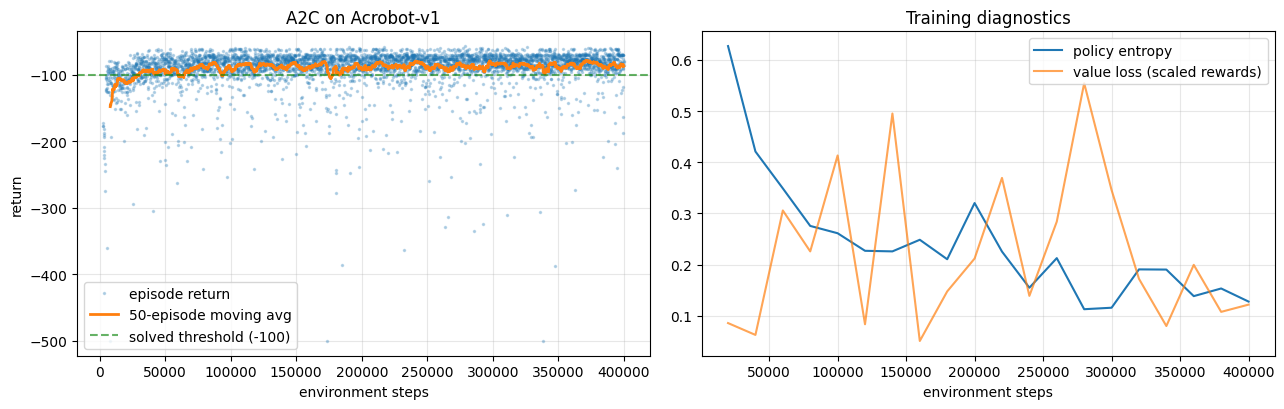

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(ep_steps, ep_returns, ".", ms=3, alpha=0.25, label="episode return")
sm = moving_average(ep_returns, 50)
axes[0].plot(ep_steps[49:], sm, lw=2, color="C1", label="50-episode moving avg")
axes[0].axhline(-100, color="green", ls="--", alpha=0.6, label="solved threshold (-100)")
axes[0].set_xlabel("environment steps"); axes[0].set_ylabel("return"); axes[0].set_title("A2C on Acrobot-v1")
axes[0].legend(); axes[0].grid(alpha=0.3)
steps = [l["step"] for l in logs]
axes[1].plot(steps, [l["entropy"] for l in logs], label="policy entropy")
axes[1].plot(steps, [l["value_loss"] for l in logs], label="value loss (scaled rewards)", alpha=0.7)
axes[1].set_xlabel("environment steps"); axes[1].set_title("Training diagnostics"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.** The first episodes hit the 500-step timeout (return $-500$). As soon as a few of the 16
environments stumble into a swing-up, the $n$-step returns and the critic propagate that information back, and returns
improve rapidly to the $-100$ region, where they plateau (the reward threshold for "solved" is $-100$; a very good
policy reaches about $-70$). Policy entropy decreases as the policy commits, but the entropy bonus keeps it from
collapsing to zero (the maximum for 3 actions is $\ln 3 \approx 1.10$).

### 6.1 Evaluating the trained policy

In [11]:
def act_greedy(obs):
    with torch.no_grad():
        dist, _ = agent(torch.as_tensor(obs, dtype=torch.float32, device=device))
    return int(dist.probs.argmax().item())

def act_sample(obs):
    with torch.no_grad():
        dist, _ = agent(torch.as_tensor(obs, dtype=torch.float32, device=device))
    return int(dist.sample().item())

eval_env = gym.make(cfg.env_id)
for name, fn in [("greedy", act_greedy), ("stochastic", act_sample)]:
    rets = []
    for i in range(10):
        o, _ = eval_env.reset(seed=500 + i); done, R = False, 0.0
        while not done:
            o, r, term, trunc, _ = eval_env.step(fn(o)); R += r; done = term or trunc
        rets.append(R)
    print(f"{name:10s} policy: mean return {np.mean(rets):7.1f} over 10 episodes (min {np.min(rets):.0f}, max {np.max(rets):.0f})")

greedy     policy: mean return   -80.9 over 10 episodes (min -97, max -69)


stochastic policy: mean return   -87.1 over 10 episodes (min -140, max -62)


## 7. Visual Demonstration

The acrobot has to *pump energy* into the system — swinging back and forth with growing amplitude — before it can lift
its tip above the target line. Watch the swing amplitude grow in the filmstrip, then the episode end as the tip crosses
the line.

Recorded episode: return -73, length 74 steps


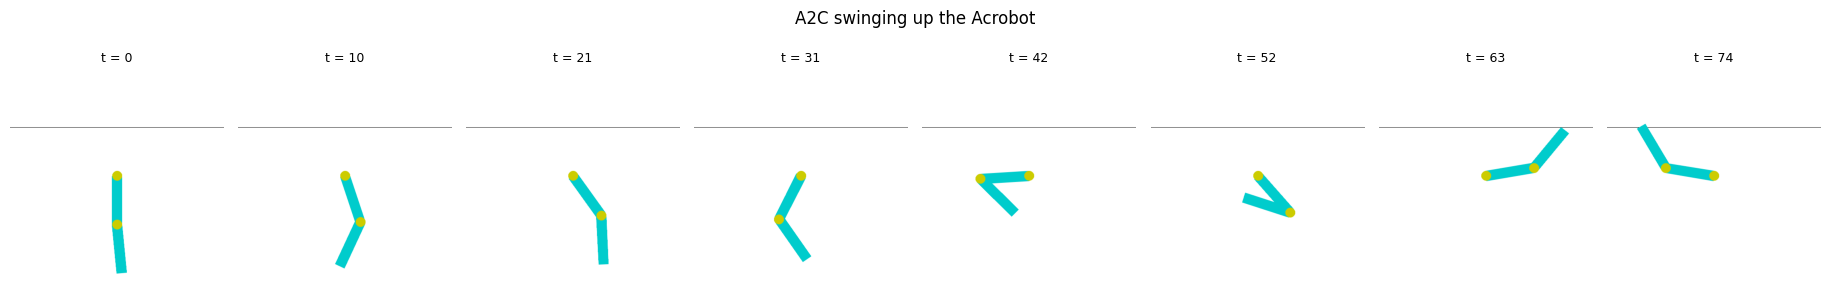

In [12]:
render_env = gym.make(cfg.env_id, render_mode="rgb_array")
frames, ep_ret, ep_len = record_episode(render_env, act_greedy, seed=1, max_steps=500)
render_env.close()
print(f"Recorded episode: return {ep_ret:.0f}, length {ep_len} steps")
show_filmstrip(frames, n=8, title="A2C swinging up the Acrobot")

Saved media/a2c_acrobot.gif  (75 frames, 0.06 MB)


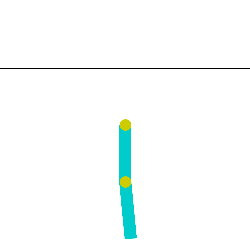

In [13]:
save_gif(frames, "a2c_acrobot", fps=25)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Simple, fast, general.** One network, one loss, one gradient step per rollout; discrete or continuous actions;
  no replay buffer to manage.
- **Bootstrapping** lets it learn from partial episodes and long-horizon / continuing tasks; the critic makes updates
  much lower-variance than REINFORCE.
- **Parallel environments** give high throughput and decorrelated data; A3C showed it could train Atari agents on
  commodity CPUs.

### Weaknesses

- **Sample inefficient.** Each sample is used once. PPO's multiple epochs per rollout typically get 3–10× more out of
  the same data; off-policy methods far more.
- **Step size is uncontrolled.** A single large policy update can be destructive, and there is no trust-region or
  clipping — this is exactly what TRPO/PPO add.
- **Bias from bootstrapping.** With a poor critic, $n$-step advantages are systematically wrong; the choice of $n$ is
  a sensitive hyperparameter.
- **Sensitive to the entropy coefficient**: too small and the policy collapses early, too large and it never commits.

### Connections

- **REINFORCE with baseline** is A2C with $n = \infty$ (no bootstrapping) and no entropy term.
- **PPO** is A2C with longer rollouts, GAE, several minibatch epochs per rollout and a clipped objective. The
  actor-critic loss with an entropy bonus is identical.
- **IMPALA** (Espeholt et al., 2018) scales the A3C actor-learner architecture to thousands of actors, using the
  **V-trace** off-policy correction to tolerate stale actors. It trained agents on all 57 Atari games and DMLab-30
  simultaneously and later powered AlphaStar's StarCraft II agent.
- **ACKTR** replaces A2C's SGD with a Kronecker-factored natural gradient; **ACER** adds a replay buffer with truncated
  importance weights.

## 9. References

1. **Mnih, V., Badia, A. P., Mirza, M., Graves, A., Lillicrap, T., Harley, T., Silver, D., & Kavukcuoglu, K.** (2016). *Asynchronous methods for deep reinforcement learning.* ICML. [[pdf]](https://arxiv.org/abs/1602.01783)
2. **Barto, A. G., Sutton, R. S., & Anderson, C. W.** (1983). *Neuronlike adaptive elements that can solve difficult learning control problems.* IEEE Trans. SMC.
3. **Konda, V. R., & Tsitsiklis, J. N.** (2000). *Actor-critic algorithms.* NeurIPS.
4. **Williams, R. J., & Peng, J.** (1991). *Function optimization using connectionist reinforcement learning algorithms.* Connection Science.
5. **Wu, Y., Mansimov, E., Liao, S., Grosse, R., & Ba, J.** (2017). *Scalable trust-region method for deep RL using Kronecker-factored approximation.* NeurIPS (ACKTR); also introduced the name "A2C".
6. **Pardo, F., Tavakoli, A., Levdik, V., & Kormushev, P.** (2018). *Time limits in reinforcement learning.* ICML.
7. **Espeholt, L., et al.** (2018). *IMPALA: Scalable distributed deep-RL with importance weighted actor-learner architectures.* ICML.
8. **Dhariwal, P., et al.** (2017). *OpenAI Baselines.* [[GitHub]](https://github.com/openai/baselines)